# Trajectory Exploration

Goal: run a few episodes with `prod=False` to see raw degradation and identify threshold values for the heuristic policy.

**Sensors (obs columns):**
| Idx | Name | Notes |
|-----|------|-------|
| 0 | HPC_Tout | High Pressure Compressor Temp Out — tracks wear |
| 1 | HP_Nmech | HP Shaft Speed |
| 2 | HPC_Tin | HP Compressor Temp In |
| 3 | LPT_Tin | Low Pressure Turbine Temp In — also tracks wear |
| 4 | Fuel_flow | Fuel consumption |
| 5 | HPC_Pout_st | HP Compressor Pressure Out |
| 6 | LP_Nmech | LP Shaft Speed |
| 7 | phase_type | Flight phase |
| 8 | DTAMB | Ambient temperature deviation |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dotenv import load_dotenv
import os

load_dotenv()
from student_client import create_student_gym_env

SENSOR_NAMES = ['HPC_Tout', 'HP_Nmech', 'HPC_Tin', 'LPT_Tin',
                'Fuel_flow', 'HPC_Pout_st', 'LP_Nmech', 'phase_type', 'DTAMB']

print('Setup done.')

Setup done.


## 1. Collect raw trajectories with `prod=False`

This gives us access to `degradation` and `max_degradation` in the info dict, which we can't see in production mode.


In [3]:
def run_do_nothing_episode(env):
    """Run a full episode doing nothing (action=0) to observe natural degradation."""
    obs, info = env.reset()
    
    all_obs = [obs]   # obs is shape (10, 9)
    all_rewards = []
    all_infos = [info]
    
    for _ in range(200):  # up to 200 decision steps = 2000 flights
        obs, reward, terminated, truncated, info = env.step(action=0)
        all_obs.append(obs)
        all_rewards.append(reward)
        all_infos.append(info)
        if terminated or truncated:
            break
    
    # Flatten observations: list of (10,9) -> (N, 9)
    flat_obs = np.vstack(all_obs)   # (total_flights, 9)
    return flat_obs, all_rewards, all_infos


env = create_student_gym_env(prod=False)

N_EPISODES = 5
trajectories = []

for ep in range(N_EPISODES):
    flat_obs, rewards, infos = run_do_nothing_episode(env)
    trajectories.append({'obs': flat_obs, 'rewards': rewards, 'infos': infos})
    total_r = sum(rewards)
    length = flat_obs.shape[0]
    last_info = infos[-1]
    print(f'Episode {ep+1}: length={length} flights, total_reward={total_r:.1f}, last_info={last_info}')

env.close()
print('Done collecting trajectories.')

2026-03-10 18:21:11,818 - student_client.student_gym_env - INFO - Client is up to date (version 0.4)
2026-03-10 18:21:14,703 - student_client.student_gym_env - INFO - Created new session: f4b2ec12-8256-48fa-a108-66d08e763ff5
2026-03-10 18:21:18,331 - student_client.student_gym_env - INFO - Created new episode: 88046f9f-a8d8-4ad1-875a-6d6c4eaa3e17
2026-03-10 18:21:18,333 - student_client.student_gym_env - INFO - StudentGymEnv initialized with episode 88046f9f-a8d8-4ad1-875a-6d6c4eaa3e17
2026-03-10 18:21:22,041 - student_client.student_gym_env - INFO - 🔄 Episode ID changed from 88046f9f-a8d8-4ad1-875a-6d6c4eaa3e17 to 0389242a-4c3b-43b3-a4de-4878b16fdf19 (old episode had steps)
2026-03-10 18:21:22,041 - student_client.student_gym_env - INFO - Episode 0389242a-4c3b-43b3-a4de-4878b16fdf19 reset successfully


Episode 0389242a-4c3b-43b3-a4de-4878b16fdf19 reached termination state, reason: failure
Episode 1: length=89 flights, total_reward=1529.3, last_info={'step': 89, 'episode_id': '0389242a-4c3b-43b3-a4de-4878b16fdf19', 'total_reward': 1529.3448570576484, 'terminated': False, 'truncated': False}


2026-03-10 18:22:10,641 - student_client.student_gym_env - INFO - 🔄 Episode ID changed from 0389242a-4c3b-43b3-a4de-4878b16fdf19 to 83e452d7-ef8f-4562-9f98-1205eee71239 (old episode had steps)
2026-03-10 18:22:10,641 - student_client.student_gym_env - INFO - Episode 83e452d7-ef8f-4562-9f98-1205eee71239 reset successfully


Episode 83e452d7-ef8f-4562-9f98-1205eee71239 reached termination state, reason: failure
Episode 2: length=120 flights, total_reward=1844.3, last_info={'step': 120, 'episode_id': '83e452d7-ef8f-4562-9f98-1205eee71239', 'total_reward': 1844.2626134389411, 'terminated': False, 'truncated': False}


2026-03-10 18:23:32,272 - student_client.student_gym_env - INFO - 🔄 Episode ID changed from 83e452d7-ef8f-4562-9f98-1205eee71239 to 4a79dde9-75e7-4d15-957a-0bc0e20ffd64 (old episode had steps)
2026-03-10 18:23:32,272 - student_client.student_gym_env - INFO - Episode 4a79dde9-75e7-4d15-957a-0bc0e20ffd64 reset successfully


Episode 4a79dde9-75e7-4d15-957a-0bc0e20ffd64 reached termination state, reason: failure
Episode 3: length=119 flights, total_reward=1863.6, last_info={'step': 119, 'episode_id': '4a79dde9-75e7-4d15-957a-0bc0e20ffd64', 'total_reward': 1863.608277493311, 'terminated': False, 'truncated': False}


2026-03-10 18:24:53,574 - student_client.student_gym_env - INFO - 🔄 Episode ID changed from 4a79dde9-75e7-4d15-957a-0bc0e20ffd64 to b4a6bccc-5ebf-42af-9558-85aa3fe62d8c (old episode had steps)
2026-03-10 18:24:53,577 - student_client.student_gym_env - INFO - Episode b4a6bccc-5ebf-42af-9558-85aa3fe62d8c reset successfully


Episode b4a6bccc-5ebf-42af-9558-85aa3fe62d8c reached termination state, reason: failure
Episode 4: length=126 flights, total_reward=1843.1, last_info={'step': 126, 'episode_id': 'b4a6bccc-5ebf-42af-9558-85aa3fe62d8c', 'total_reward': 1843.072957048164, 'terminated': False, 'truncated': False}


2026-03-10 18:26:16,064 - student_client.student_gym_env - INFO - 🔄 Episode ID changed from b4a6bccc-5ebf-42af-9558-85aa3fe62d8c to 3273c61e-bd72-4ab6-b5c8-dfc654bec140 (old episode had steps)
2026-03-10 18:26:16,065 - student_client.student_gym_env - INFO - Episode 3273c61e-bd72-4ab6-b5c8-dfc654bec140 reset successfully
2026-03-10 18:27:17,840 - student_client.student_gym_env - ERROR - Failed to step episode 3273c61e-bd72-4ab6-b5c8-dfc654bec140: Server error '500 Internal Server Error' for url 'http://rlchallenge.orailix.com/api/v1/episode/step'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/500
2026-03-10 18:27:17,840 - student_client.student_gym_env - INFO - Closed environment 3273c61e-bd72-4ab6-b5c8-dfc654bec140


Episode 5: length=122 flights, total_reward=2934.8, last_info={'error': "Server error '500 Internal Server Error' for url 'http://rlchallenge.orailix.com/api/v1/episode/step'\nFor more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/500", 'step': 120}
Done collecting trajectories.


## 2. Plot sensors for each episode

Look for the sensors that trend upward as the engine degrades. Vertical red lines mark failure (terminated).


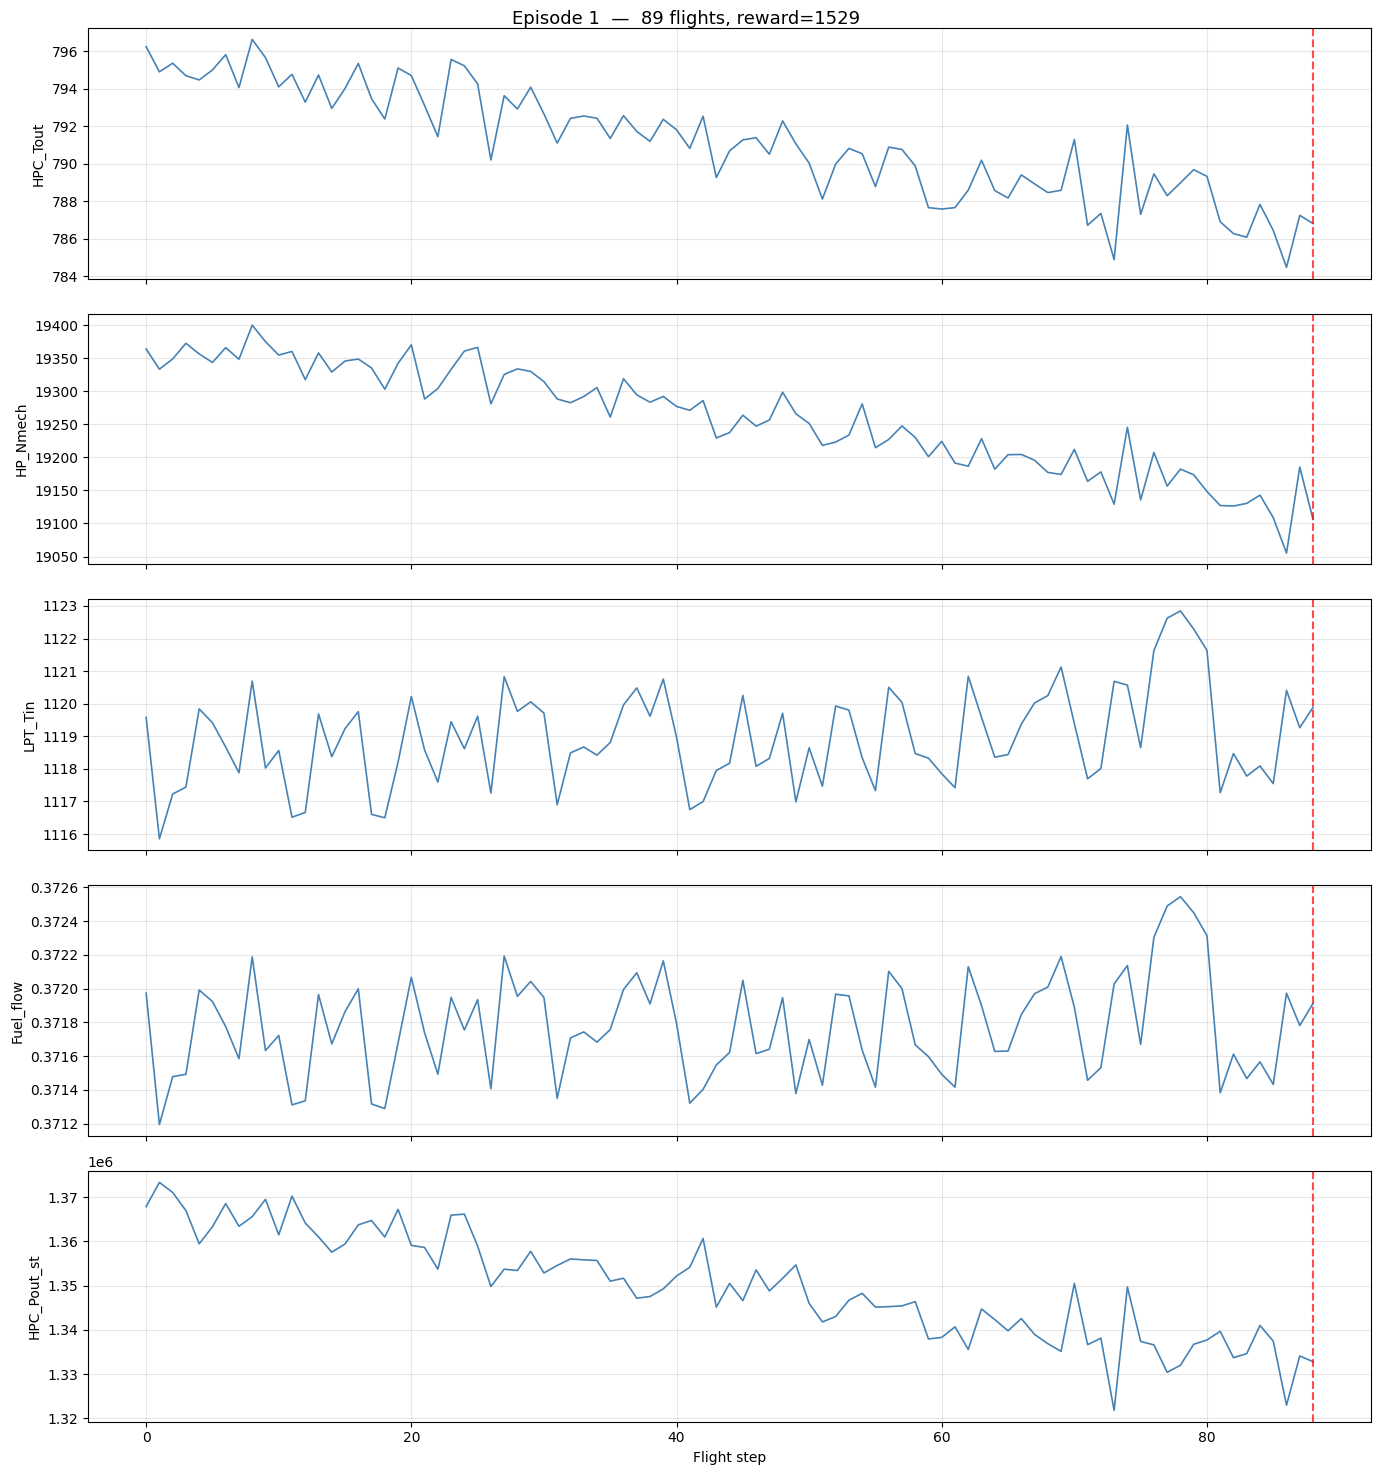

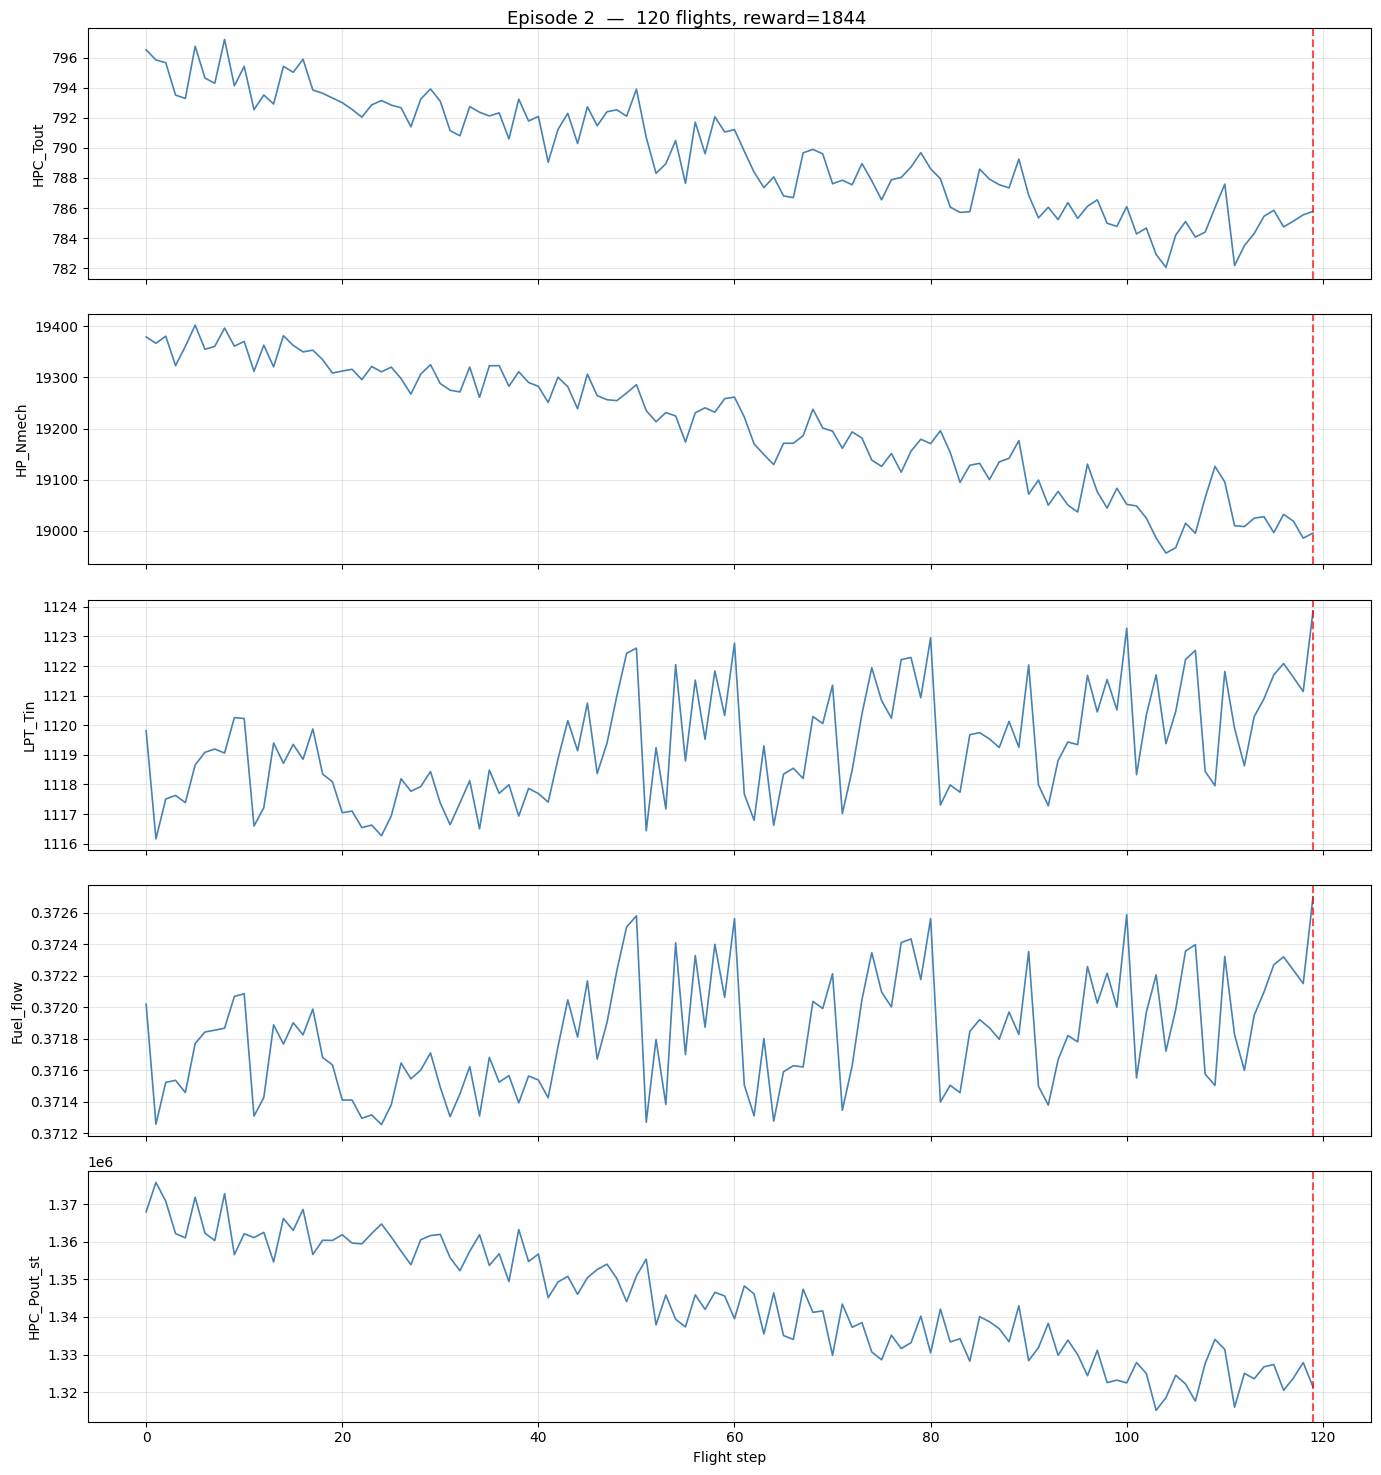

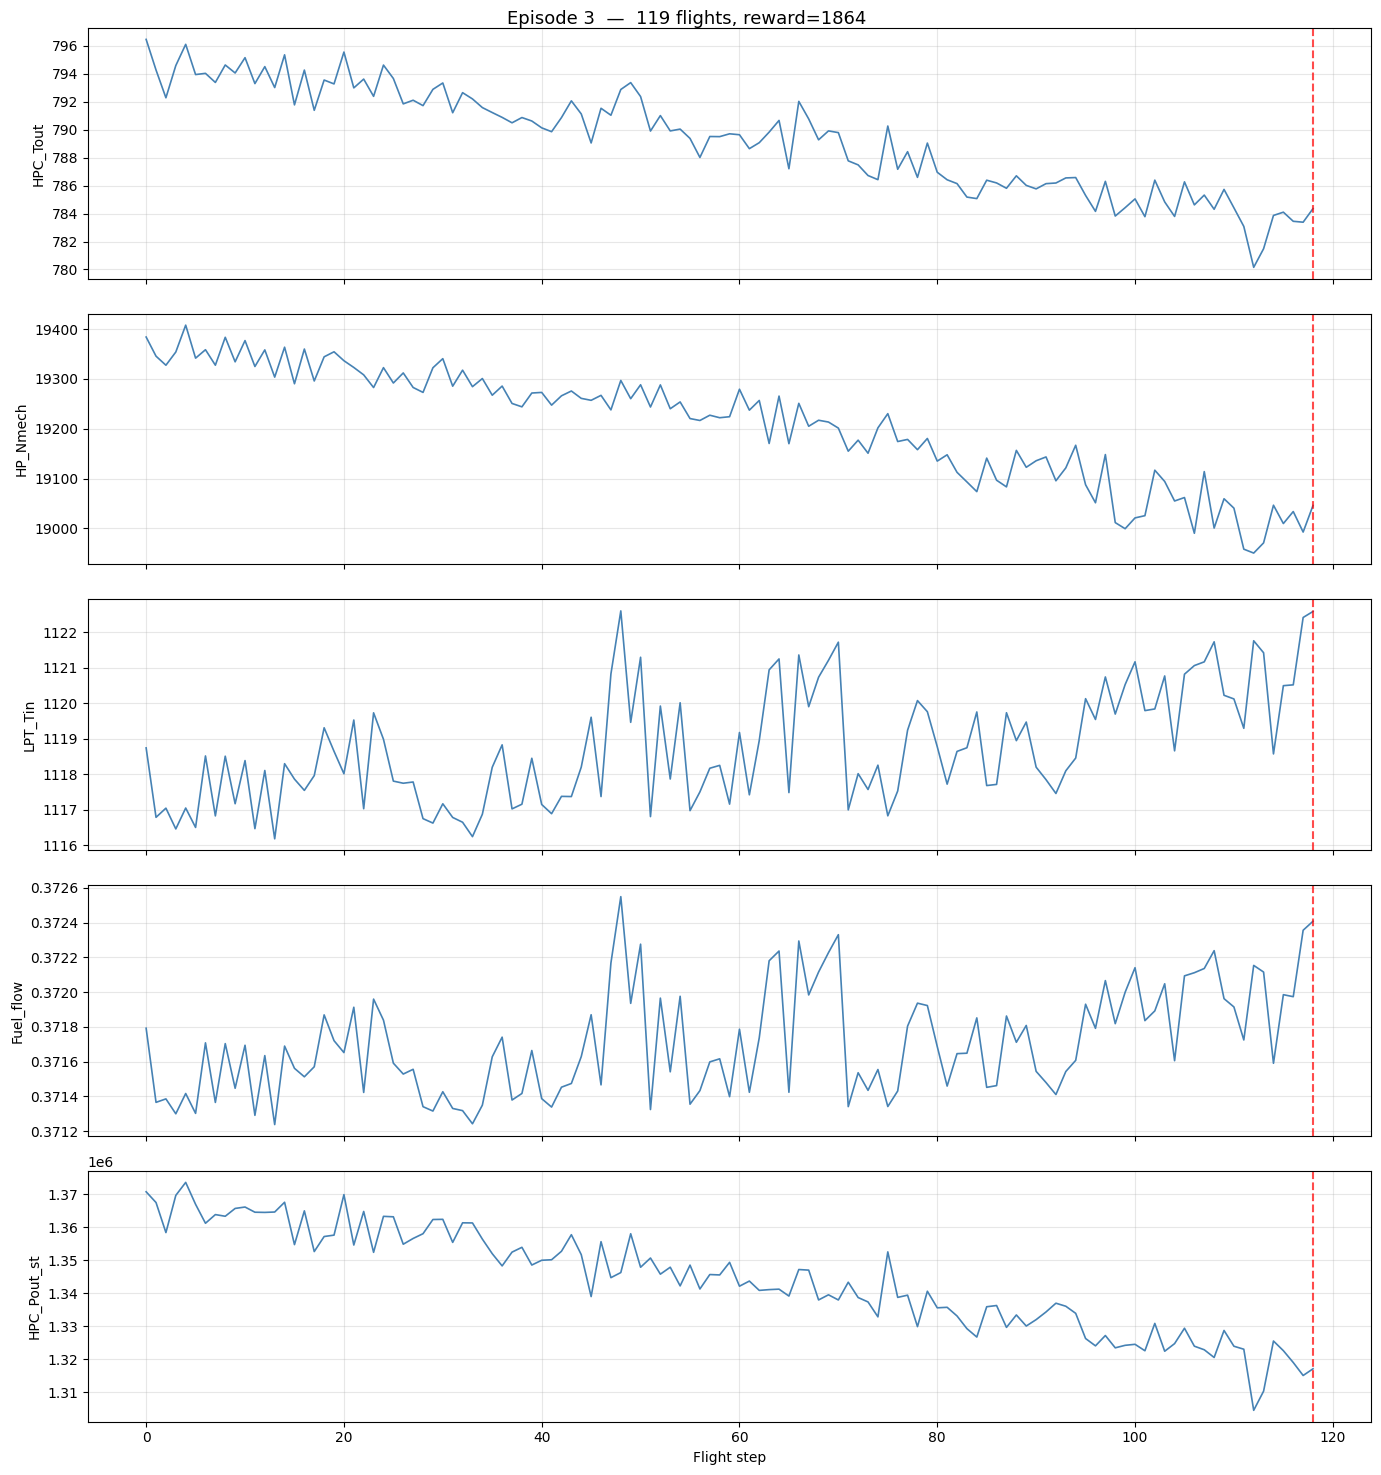

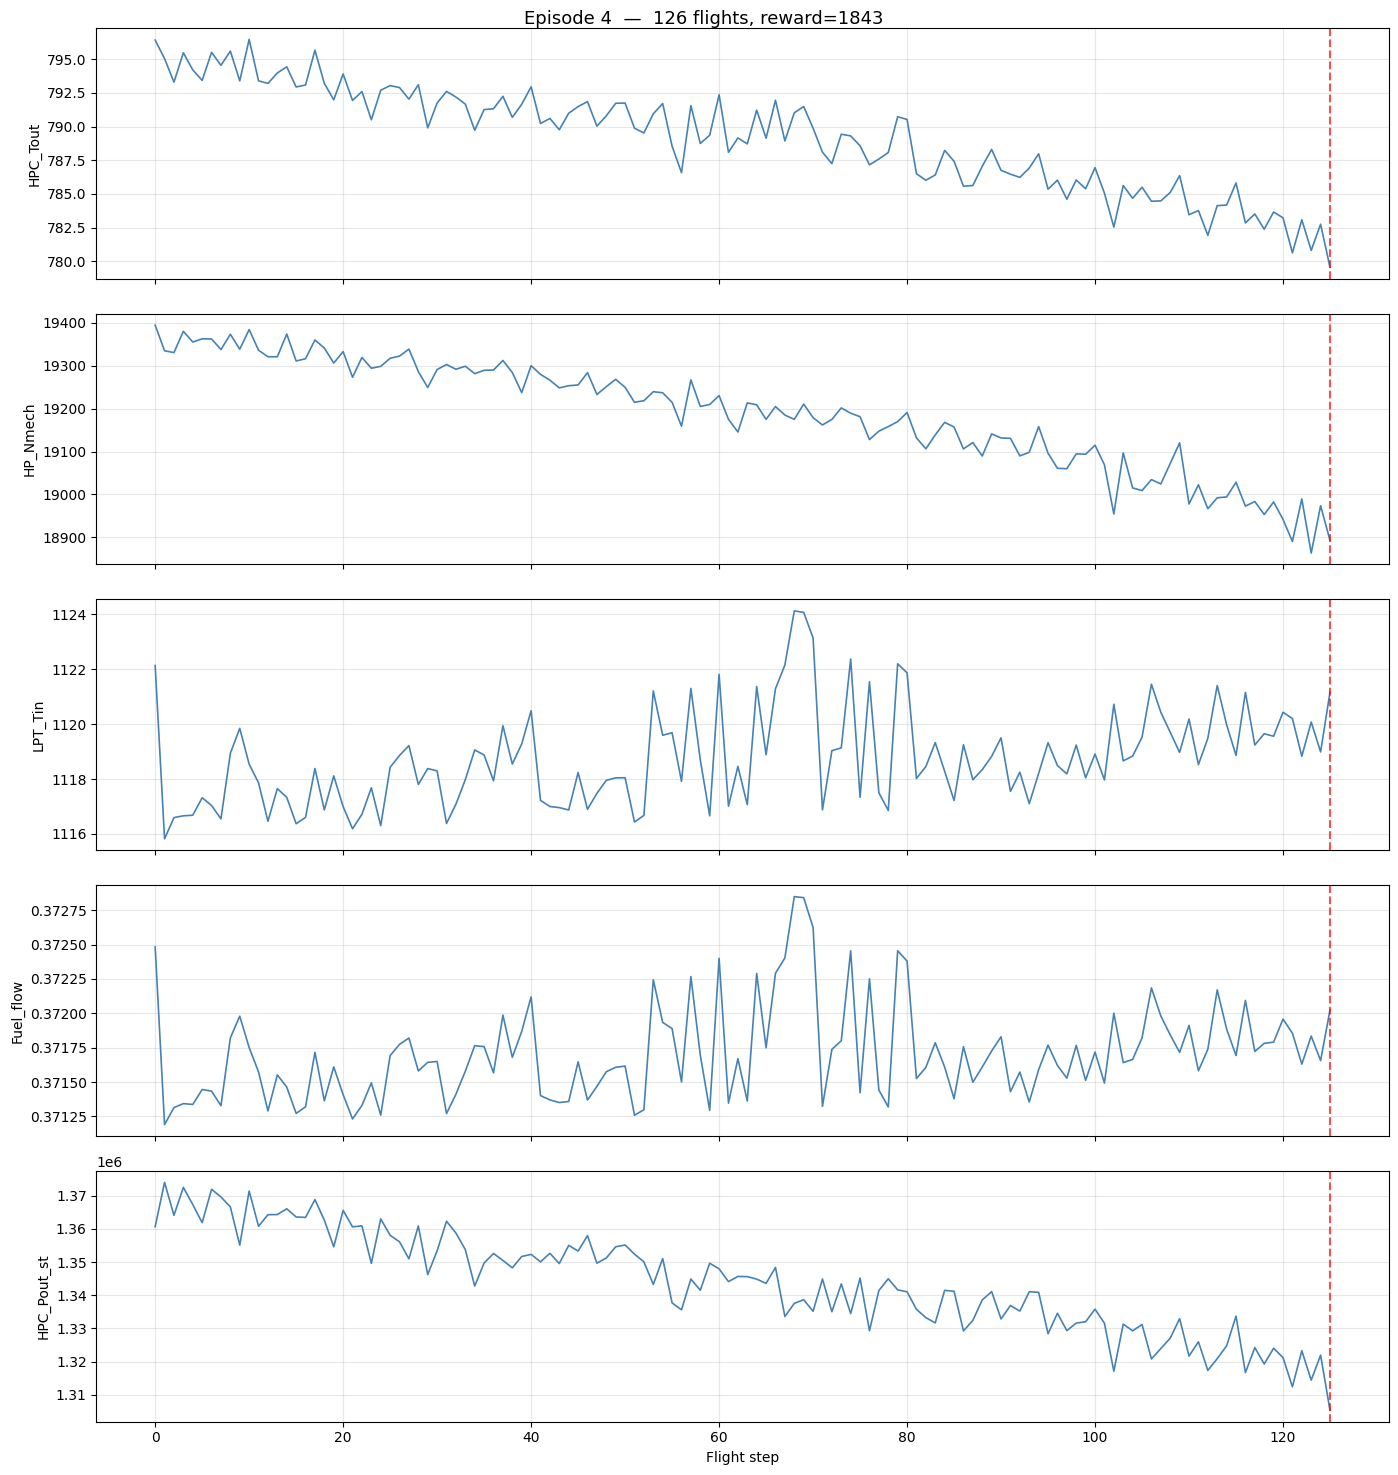

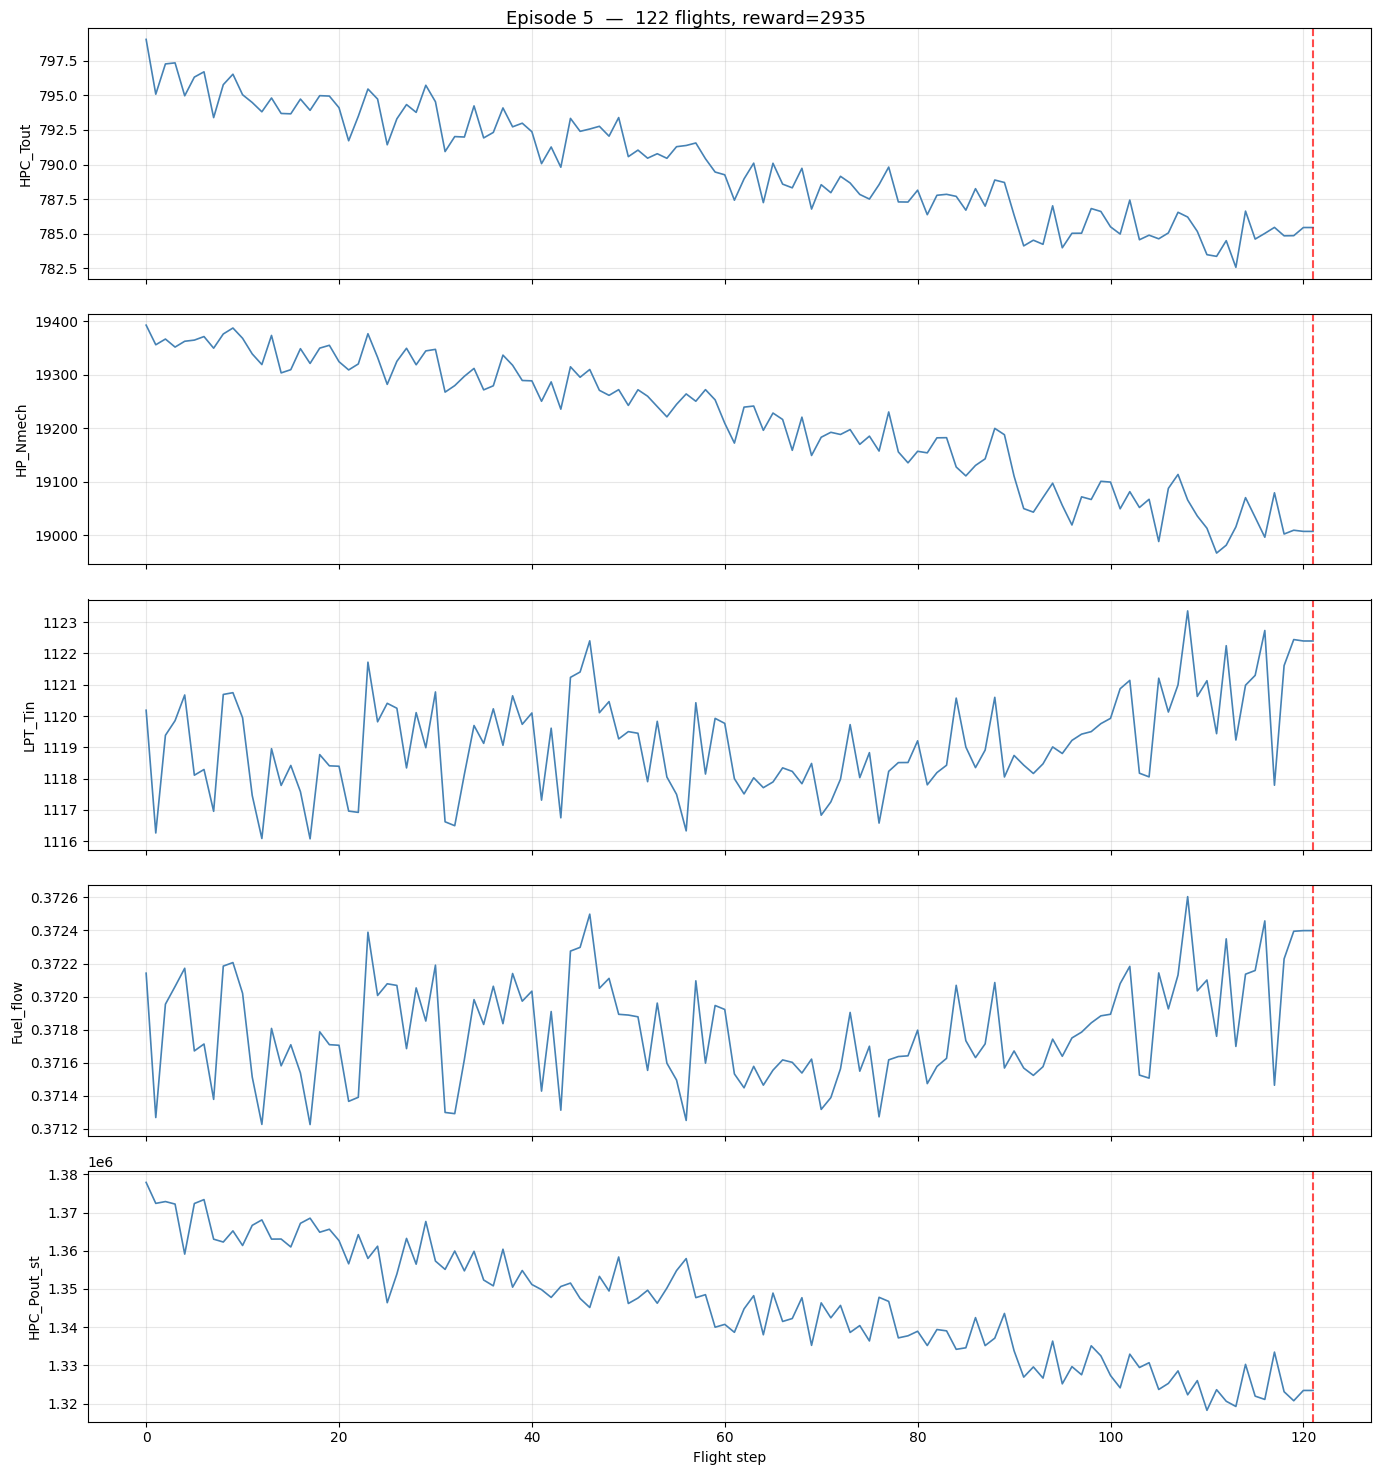

In [4]:
def plot_trajectory(traj, ep_idx, sensors_to_plot=(0, 3, 4)):
    """Plot selected sensors for one trajectory."""
    obs = traj['obs']           # (N_flights, 9)
    infos = traj['infos']
    
    n_flights = obs.shape[0]
    steps = np.arange(n_flights)
    
    # Did it end in failure?
    last_info = infos[-1]
    failed = last_info.get('terminated', False) and last_info.get('message', '').lower().find('fail') >= 0
    
    fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(14, 3 * len(sensors_to_plot)), sharex=True)
    fig.suptitle(f'Episode {ep_idx+1}  —  {n_flights} flights, reward={sum(traj["rewards"]):.0f}', fontsize=13)
    
    for ax, s in zip(axes, sensors_to_plot):
        ax.plot(steps, obs[:, s], linewidth=1.2, color='steelblue')
        ax.set_ylabel(SENSOR_NAMES[s], fontsize=10)
        ax.grid(True, alpha=0.3)
        # Mark end
        ax.axvline(n_flights - 1, color='red', linestyle='--', alpha=0.7, label='episode end')
    
    axes[-1].set_xlabel('Flight step', fontsize=10)
    plt.tight_layout()
    plt.show()


for i, traj in enumerate(trajectories):
    plot_trajectory(traj, i, sensors_to_plot=(0, 1, 3, 4, 5))

## 3. Distribution of sensor values at failure vs. healthy

Compare the last 10 flights before failure against the first 50 flights of the episode.


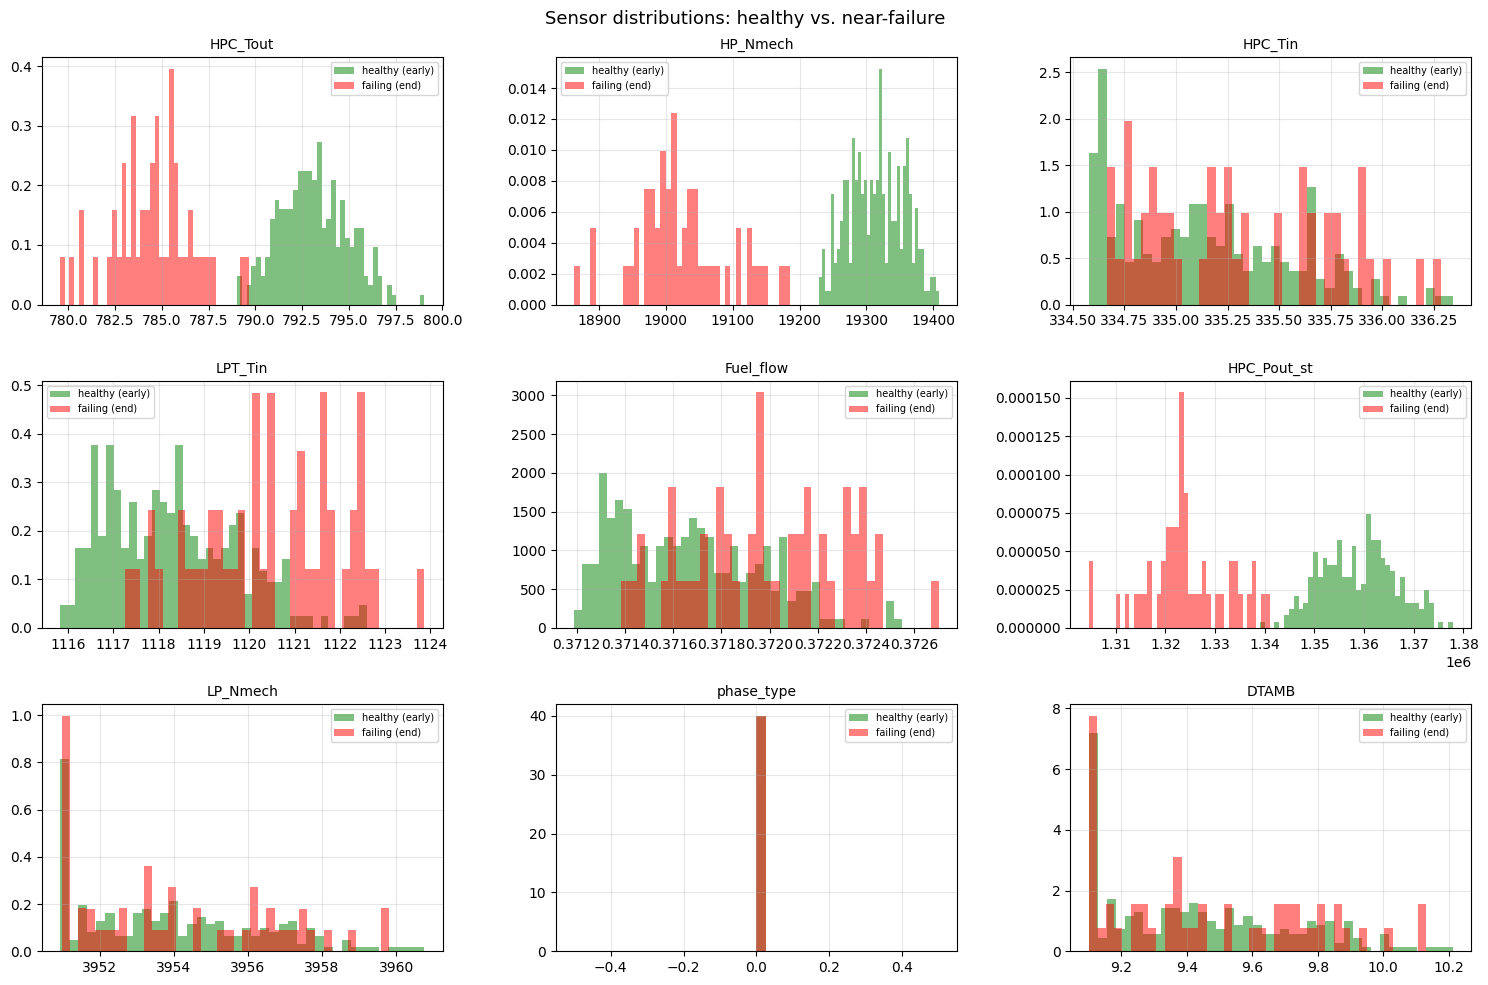


Sensor means:
Sensor             Healthy mean    Failing mean      Ratio
----------------------------------------------------------
HPC_Tout               793.1274        784.5436     0.9892
HP_Nmech             19315.3555      19025.0508     0.9850
HPC_Tin                335.1327        335.2941     1.0005
LPT_Tin               1118.3140       1120.4884     1.0019
Fuel_flow                0.3717          0.3720     1.0009
HPC_Pout_st        1358857.5000    1324088.7500     0.9744
LP_Nmech              3953.8816       3954.1309     1.0001
phase_type               0.0000          0.0000        nan
DTAMB                    9.4412          9.4686     1.0029


In [9]:
WINDOW = 10  # last N flights before failure
HEALTHY_END = 50  # first N flights = "healthy"

healthy_vals = []
failing_vals = []

for traj in trajectories:
    obs = traj['obs']
    if obs.shape[0] > HEALTHY_END:
        healthy_vals.append(obs[:HEALTHY_END, :])
    failing_vals.append(obs[-WINDOW:, :])

healthy = np.vstack(healthy_vals)   # (N_h, 9)
failing  = np.vstack(failing_vals)  # (N_f, 9)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(9):
    ax = axes[i]
    ax.hist(healthy[:, i], bins=40, alpha=0.5, label='healthy (early)', color='green', density=True)
    ax.hist(failing[:, i],  bins=40, alpha=0.5, label='failing (end)',   color='red',   density=True)
    ax.set_title(SENSOR_NAMES[i], fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sensor distributions: healthy vs. near-failure', fontsize=13)
plt.tight_layout()
plt.show()

print('\nSensor means:')
print(f'{"Sensor":15s} {"Healthy mean":>15s} {"Failing mean":>15s} {"Ratio":>10s}')
print('-' * 58)
for i, name in enumerate(SENSOR_NAMES):
    h_mean = healthy[:, i].mean()
    f_mean = failing[:, i].mean()
    ratio = f_mean / h_mean if h_mean != 0 else float('nan')
    print(f'{name:15s} {h_mean:>15.4f} {f_mean:>15.4f} {ratio:>10.4f}')

## 4. Find thresholds per sensor

For each sensor, find the value that best separates healthy from failing by maximising the separation between the two distributions.


In [6]:
print('\nSuggested per-sensor percentile thresholds (what value marks the top 10% of failing):')
print(f'{"Sensor":15s} {"90th pct (failing)":>20s} {"50th pct (healthy)":>20s}')
print('-' * 60)

thresholds = {}
for i, name in enumerate(SENSOR_NAMES):
    failing_90 = np.percentile(failing[:, i], 90)
    healthy_50 = np.percentile(healthy[:, i], 50)
    thresholds[name] = {'failing_90': failing_90, 'healthy_50': healthy_50}
    print(f'{name:15s} {failing_90:>20.4f} {healthy_50:>20.4f}')


Suggested per-sensor percentile thresholds (what value marks the top 10% of failing):
Sensor            90th pct (failing)   50th pct (healthy)
------------------------------------------------------------
HPC_Tout                    786.9402             793.0120
HP_Nmech                  19127.4902           19317.0234
HPC_Tin                     335.8904             335.0915
LPT_Tin                    1122.4003            1118.1947
Fuel_flow                     0.3724               0.3716
HPC_Pout_st             1334840.0000         1359097.5000
LP_Nmech                   3957.5962            3953.6040
phase_type                    0.0000               0.0000
DTAMB                         9.8718               9.4085


## 5. Compute rolling stats from a window of observations

These are the features the heuristic policy will use: last value, trend (slope), and max over the window.


In [7]:
def extract_features(obs_window):
    """
    obs_window: (10, 9) array returned by env.step()
    Returns a dict of features.
    """
    features = {}
    for i, name in enumerate(SENSOR_NAMES[:7]):  # skip phase_type, DTAMB
        col = obs_window[:, i]
        features[f'{name}_last']  = col[-1]
        features[f'{name}_mean']  = col.mean()
        features[f'{name}_max']   = col.max()
        features[f'{name}_trend'] = col[-1] - col[0]  # change over window
    return features


# Show feature statistics for the first trajectory
traj = trajectories[0]
obs = traj['obs']  # (N_flights, 9)

# Compute features at every 10-flight decision point
feature_list = []
for start in range(0, len(obs) - 10, 10):
    window = obs[start:start+10]
    feat = extract_features(window)
    feature_list.append(feat)

print(f'Number of decision points in episode 1: {len(feature_list)}')
print('\nSample features at first decision point:')
for k, v in list(feature_list[0].items())[:12]:
    print(f'  {k:25s} = {v:.4f}')

Number of decision points in episode 1: 8

Sample features at first decision point:
  HPC_Tout_last             = 795.6642
  HPC_Tout_mean             = 795.2894
  HPC_Tout_max              = 796.6373
  HPC_Tout_trend            = -0.5868
  HP_Nmech_last             = 19374.9727
  HP_Nmech_mean             = 19360.7637
  HP_Nmech_max              = 19399.9238
  HP_Nmech_trend            = 11.0566
  HPC_Tin_last              = 335.0730
  HPC_Tin_mean              = 335.2247
  HPC_Tin_max               = 335.8118
  HPC_Tin_trend             = -0.5607


## 6. Visualise degradation-proxy feature over time

Look at `HPC_Tout_last` and `LPT_Tin_last` — these are the best candidates for the heuristic threshold.


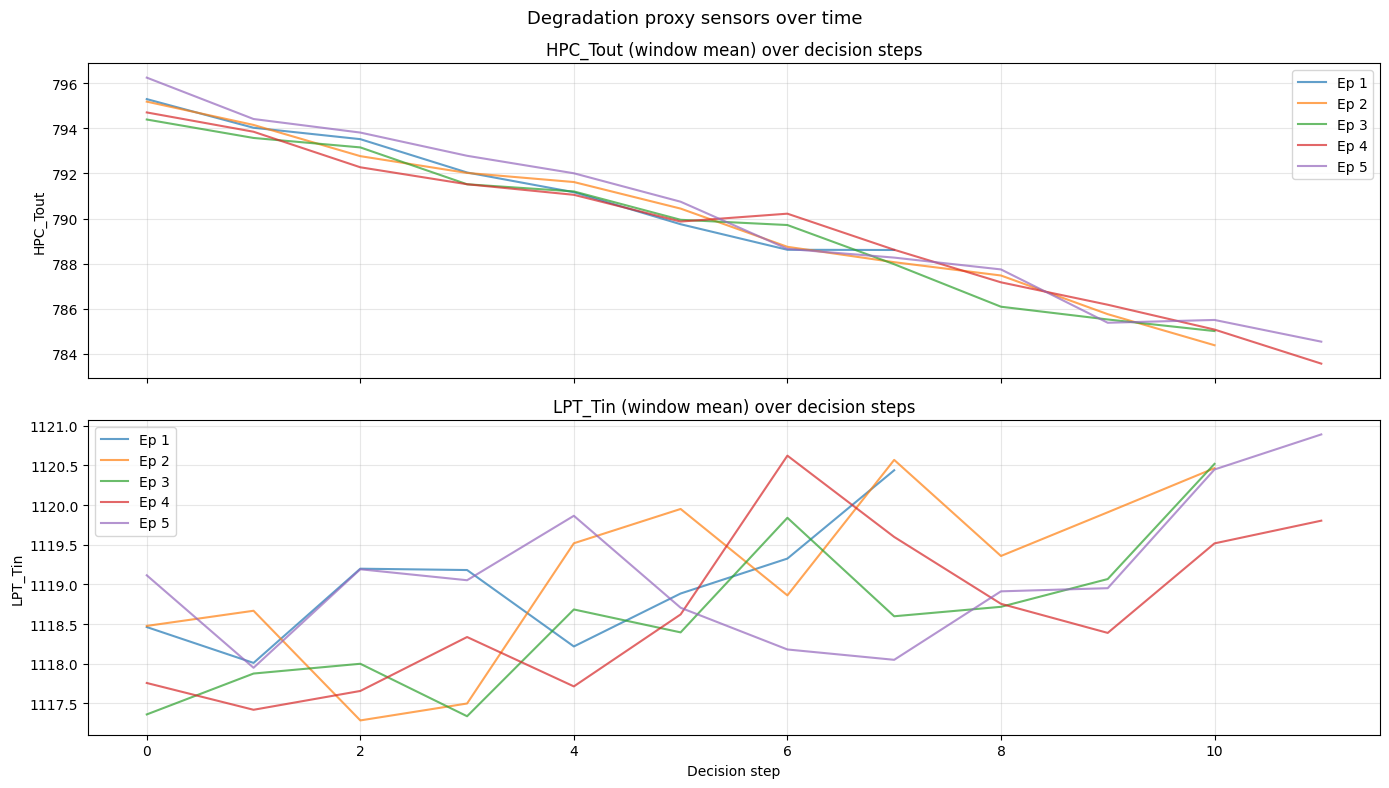


=== Use these plots to choose SELL_THRESHOLD and REPAIR_THRESHOLD for heuristic_agent.py ===
   - SELL_THRESHOLD:   HPC_Tout mean value at which ALL episodes are near failure
   - REPAIR_THRESHOLD: value at which episodes start to degrade but still have life left


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for i, traj in enumerate(trajectories):
    obs = traj['obs']
    decision_steps = range(0, len(obs) - 10, 10)
    
    hpc_tout_vals = [obs[s:s+10, 0].mean() for s in decision_steps]  # HPC_Tout mean per window
    lpt_tin_vals  = [obs[s:s+10, 3].mean() for s in decision_steps]  # LPT_Tin mean per window
    
    axes[0].plot(hpc_tout_vals, alpha=0.7, label=f'Ep {i+1}')
    axes[1].plot(lpt_tin_vals,  alpha=0.7, label=f'Ep {i+1}')

axes[0].set_title('HPC_Tout (window mean) over decision steps')
axes[0].set_ylabel('HPC_Tout')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('LPT_Tin (window mean) over decision steps')
axes[1].set_ylabel('LPT_Tin')
axes[1].set_xlabel('Decision step')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Degradation proxy sensors over time', fontsize=13)
plt.tight_layout()
plt.show()

print()
print('=== Use these plots to choose SELL_THRESHOLD and REPAIR_THRESHOLD for heuristic_agent.py ===')
print('   - SELL_THRESHOLD:   HPC_Tout mean value at which ALL episodes are near failure')
print('   - REPAIR_THRESHOLD: value at which episodes start to degrade but still have life left')

## 7. Test a simple threshold heuristic inline

Run the heuristic here before committing to `heuristic_agent.py`.


In [10]:
# NOTE: HPC_Tout DECREASES as the engine degrades (lower = worse).
#   Healthy mean : ~793  |  Failing mean: ~785  |  Failing 90th pct: 786.9
# Logic: sell when mean is too LOW; repair when mean is falling and trending down.

SELL_THRESHOLD   = 787.0  # HPC_Tout mean BELOW this -> sell  (below failing 90th pct)
REPAIR_THRESHOLD = 790.5  # HPC_Tout mean BELOW this -> consider repair
TREND_THRESHOLD  = -1.5   # HPC_Tout trend BELOW this (negative) -> engine worsening

def heuristic_action(obs_window):
    # obs_window: (10, 9)
    hpc_tout_mean  = obs_window[:, 0].mean()
    hpc_tout_trend = obs_window[-1, 0] - obs_window[0, 0]  # negative = degrading

    if hpc_tout_mean < SELL_THRESHOLD:
        return 2  # sell — engine too degraded
    if hpc_tout_mean < REPAIR_THRESHOLD and hpc_tout_trend < TREND_THRESHOLD:
        return 1  # repair — degradation active and worsening
    return 0  # do nothing — engine still healthy

# Quick test: 10 episodes
env = create_student_gym_env(prod=False)
test_rewards = []

for ep in range(10):
    obs, info = env.reset()
    total_r = 0
    for _ in range(200):
        action = heuristic_action(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        total_r += reward
        if terminated or truncated:
            break
    test_rewards.append(total_r)

env.close()
print(f'Heuristic test — 10 episodes:')
print(f'  Total reward:   {sum(test_rewards):.1f}')
print(f'  Average reward: {np.mean(test_rewards):.1f}')
print(f'  Best reward:    {max(test_rewards):.1f}')
print(f'  Per episode:    {[f"{r:.0f}" for r in test_rewards]}')
print()
print('Compare: Baseline 1 avg = 3951, Baseline 2 avg = 3111')

2026-03-10 18:54:02,282 - student_client.student_gym_env - INFO - Client is up to date (version 0.4)
2026-03-10 18:54:09,475 - student_client.student_gym_env - INFO - Created new session: 20152bf3-010e-4c61-b76d-a3df0e418680
2026-03-10 18:54:13,055 - student_client.student_gym_env - INFO - Created new episode: a86ce7b0-28d6-4044-9992-3c1853037224
2026-03-10 18:54:13,136 - student_client.student_gym_env - INFO - StudentGymEnv initialized with episode a86ce7b0-28d6-4044-9992-3c1853037224
2026-03-10 18:54:16,483 - student_client.student_gym_env - INFO - 🔄 Episode ID changed from a86ce7b0-28d6-4044-9992-3c1853037224 to 0801bebc-9b69-487a-ae2e-7aaaaf8eebfe (old episode had steps)
2026-03-10 18:54:16,487 - student_client.student_gym_env - INFO - Episode 0801bebc-9b69-487a-ae2e-7aaaaf8eebfe reset successfully


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed